<a href="https://colab.research.google.com/github/momensaleh193-png/NTI-ML-/blob/main/momen_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error



In [10]:
df = pd.read_csv("house_prices.csv")
df.head(10)

,size_sqft,bedrooms,bathrooms,age_years,distance_to_city_km,price
0,2098.0,2,2.0,40,5.64,296100.0
1,1717.0,2,2.0,0,2.12,262324.0
2,2188.6,3,1.0,4,0.67,336459.0
3,2713.8,3,3.0,19,11.99,382157.0
4,1659.5,5,3.0,7,1.04,301238.0
5,1659.5,5,1.0,42,7.22,288823.0
6,2747.5,1,1.0,11,22.05,367620.0
7,2260.5,1,2.0,0,16.71,321675.0
8,1518.3,5,1.0,19,NaN,272179.0
9,2125.5,5,3.0,27,15.25,325389.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   size_sqft            482 non-null    float64
 1   bedrooms             502 non-null    int64  
 2   bathrooms            482 non-null    float64
 3   age_years            502 non-null    int64  
 4   distance_to_city_km  482 non-null    float64
 5   price                502 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 23.7 KB


In [12]:
df.describe()

,size_sqft,bedrooms,bathrooms,age_years,distance_to_city_km,price
count,482.000000,502.000000,482.000000,502.000000,482.000000,5.020000e+02
mean,1837.610373,2.966135,1.977178,24.274900,7.795145,2.906788e+05
std,667.887996,1.421551,0.806353,14.873389,7.896412,1.185166e+05
min,400.000000,1.000000,1.000000,0.000000,0.500000,8.110200e+04
25%,1383.575000,2.000000,1.000000,11.000000,2.010000,2.314652e+05
50%,1835.500000,3.000000,2.000000,24.000000,5.315000,2.856030e+05
75%,2200.675000,4.000000,3.000000,37.000000,11.060000,3.299068e+05
max,7701.200000,5.000000,3.000000,49.000000,46.680000,1.774570e+06


In [13]:
df.isna().sum()

,0
size_sqft,20
bedrooms,0
bathrooms,20
age_years,0
distance_to_city_km,20
price,0


In [14]:
df_clean = df.copy()

size_sqft_mean = df_clean["size_sqft"].mean()
df_clean["size_sqft"] = df_clean["size_sqft"].fillna(size_sqft_mean)

distance_to_city_km_mean = df_clean["distance_to_city_km"].mean()
df_clean["distance_to_city_km"] = df_clean["distance_to_city_km"].fillna(distance_to_city_km_mean)

bathrooms_mode = df_clean["bathrooms"].mode()[0]
df_clean["bathrooms"] = df_clean["bathrooms"].fillna(bathrooms_mode)

In [15]:
df_clean.isna().sum()

,0
size_sqft,0
bedrooms,0
bathrooms,0
age_years,0
distance_to_city_km,0
price,0


In [16]:
df_clean.drop_duplicates(inplace=True)

In [17]:
print("after cleaning")
df_clean.isna().sum()



after cleaning


,0
size_sqft,0
bedrooms,0
bathrooms,0
age_years,0
distance_to_city_km,0
price,0


In [18]:
print("duplicates" , df_clean.duplicated().sum())
print("the new shape ")
df_clean.shape

duplicates 0
the new shape 


(500, 6)

                     size_sqft  bedrooms  bathrooms  age_years  \
size_sqft             1.000000 -0.015747   0.062656  -0.016965   
bedrooms             -0.015747  1.000000   0.018992  -0.068334   
bathrooms             0.062656  0.018992   1.000000  -0.046796   
age_years            -0.016965 -0.068334  -0.046796   1.000000   
distance_to_city_km   0.016896  0.017561   0.074082   0.024513   
price                 0.495133  0.191595   0.047075  -0.108393   

                     distance_to_city_km     price  
size_sqft                       0.016896  0.495133  
bedrooms                        0.017561  0.191595  
bathrooms                       0.074082  0.047075  
age_years                       0.024513 -0.108393  
distance_to_city_km             1.000000 -0.083728  
price                          -0.083728  1.000000  


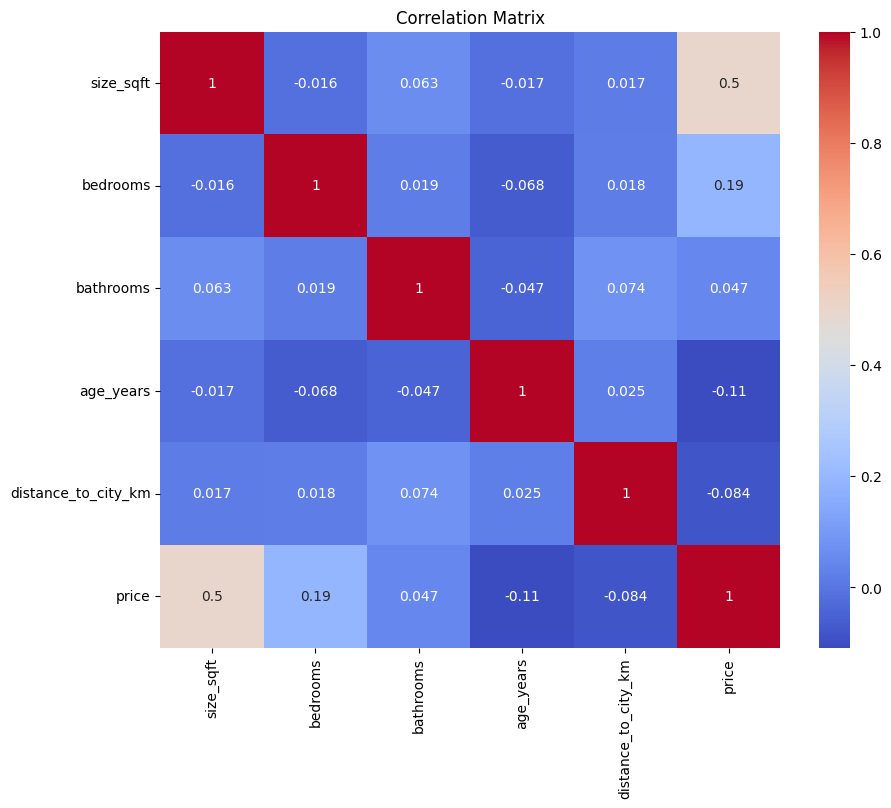

In [19]:
corr = df_clean.corr(numeric_only=True)
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

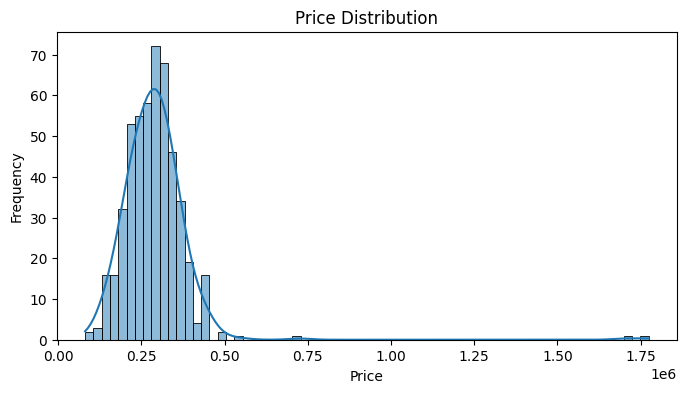

In [20]:
plt.figure(figsize=(8,4))
sns.histplot(df_clean["price"] , kde = True )

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

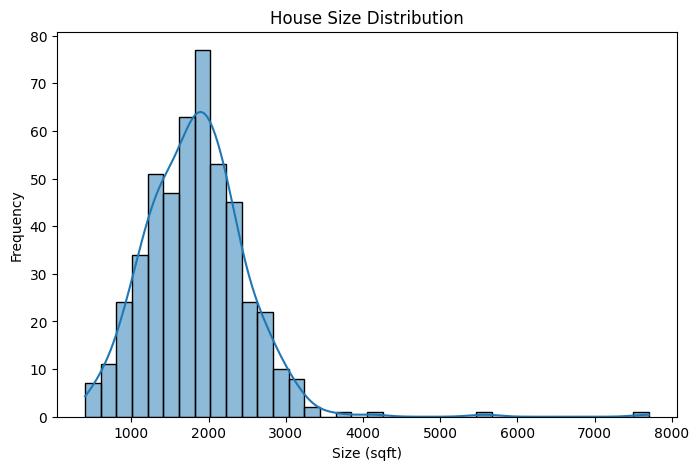

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(df["size_sqft"], kde=True)

plt.title("House Size Distribution")
plt.xlabel("Size (sqft)")
plt.ylabel("Frequency")

plt.show()

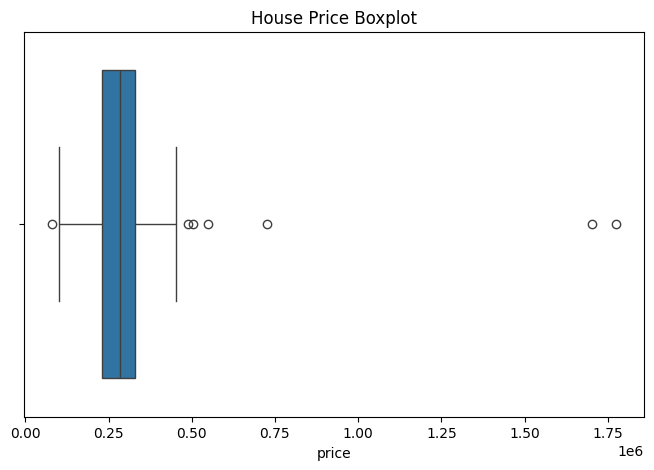

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["price"])

plt.title("House Price Boxplot")

plt.show()

In [23]:
x = df_clean[["size_sqft"]]
y = df_clean["price"]

x_train , x_test , y_train , y_test = train_test_split(
    x,y,test_size=.2,random_state=42
)

In [24]:
model = LinearRegression()
model.fit(x_train , y_train)

LinearRegression()

In [25]:
intercept = model.intercept_
coef = model.coef_[0]

print("Intercept:", intercept)
print("Coefficient:", coef)

Intercept: 136283.3884524404
Coefficient: 84.16546728457493


In [26]:
y_pred = model.predict(x_test)
rmse = mean_squared_error(y_test , y_pred)**2

In [29]:
import numpy as np

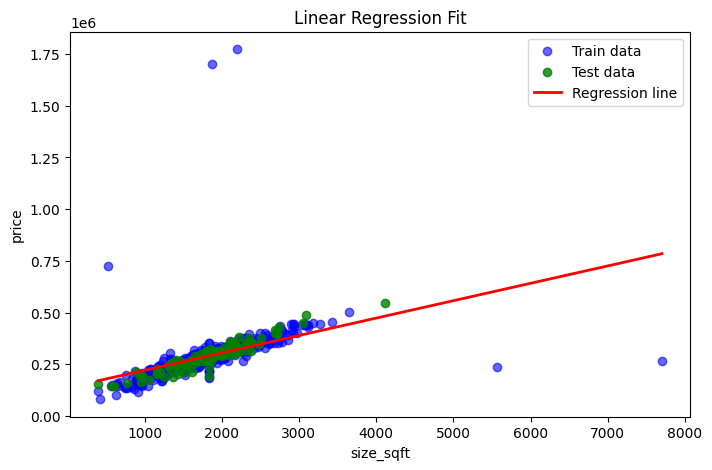

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color="blue", alpha=0.6, label="Train data")
plt.scatter(x_test, y_test, color="green", alpha=0.8, label="Test data")
x_line = np.linspace(x["size_sqft"].min(), x["size_sqft"].max(), 100).reshape(-1, 1)
plt.plot(x_line, model.predict(pd.DataFrame(x_line, columns=["size_sqft"])),
         color="red", linewidth=2, label="Regression line")
plt.xlabel("size_sqft")
plt.ylabel("price")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()